### Import relevant libraries

In [9]:
import numpy as np
from matplotlib import pyplot as plt
import math
from decimal import Decimal, getcontext
import struct

### Exercice 1

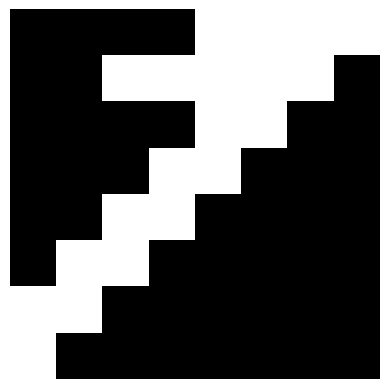

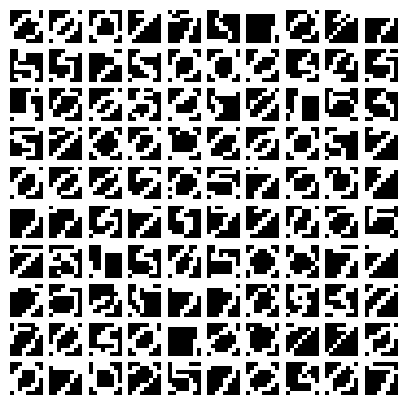

In [10]:
def main():
    # Load the data set
    Y = np.loadtxt('binarydigits.txt')
    N, D = Y.shape

    # Display an image
    y = Y[3,  :]
    plt.figure()
    plt.imshow(np.reshape(y, (8,8)),
               interpolation="None",
               cmap='gray')
    plt.axis('off')

    # Display the whole data set:
    plt.figure(figsize=(5, 5))
    for n in range(N):
        plt.subplot(10, 10, n+1)
        plt.imshow(np.reshape(Y[n, :], (8,8)),
                   interpolation="None",
                   cmap='gray')
        plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()

#### Exercice 1 Question d

[[0.13 0.21 0.29 0.43 0.64 0.77 0.69 0.5 ]
 [0.08 0.25 0.45 0.64 0.72 0.7  0.79 0.48]
 [0.13 0.3  0.45 0.39 0.27 0.25 0.5  0.52]
 [0.19 0.45 0.48 0.31 0.29 0.25 0.44 0.4 ]
 [0.32 0.39 0.19 0.26 0.23 0.4  0.54 0.26]
 [0.47 0.33 0.13 0.14 0.28 0.44 0.48 0.17]
 [0.6  0.59 0.35 0.44 0.57 0.52 0.29 0.04]
 [0.28 0.66 0.76 0.77 0.42 0.19 0.05 0.  ]]


(np.float64(-0.5), np.float64(7.5), np.float64(7.5), np.float64(-0.5))

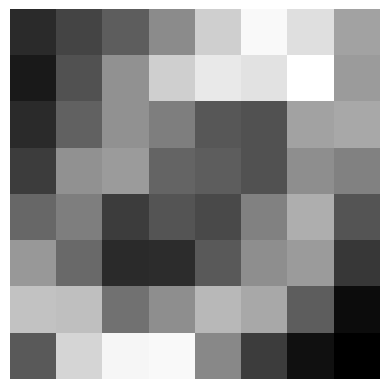

In [11]:
#We load the dataset
X = np.loadtxt('binarydigits.txt')

def ML_parameters(input):
    """
    Compute the maximum likelihood estimate of parameters.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Binary input data where X[n, d] ∈ {0, 1} indicates success/failure for feature d on sample n.

    Returns
    -------
    p : numpy.ndarray of shape (n_features,)
        Estimated success probabilities p[d] = (1/n_samples) · ∑ₙ X[n, d].
    """
    N, D = input.shape
    p=np.zeros(shape=D)
    for d in range (D):
        pd=0
        for n in range (N):
            pd+=input[n,d]
        p[d]=pd/N
    return p 

#We print the numerical result
print(ML_parameters(X).reshape((8,8)))

#We print the resulting image
plt.figure()
plt.imshow(np.reshape(ML_parameters(X), (8,8)),
           interpolation="None",cmap='gray')
plt.axis('off')

#### Exercice 1 Question e

[[0.14423077 0.22115385 0.29807692 0.43269231 0.63461538 0.75961538
  0.68269231 0.5       ]
 [0.09615385 0.25961538 0.45192308 0.63461538 0.71153846 0.69230769
  0.77884615 0.48076923]
 [0.14423077 0.30769231 0.45192308 0.39423077 0.27884615 0.25961538
  0.5        0.51923077]
 [0.20192308 0.45192308 0.48076923 0.31730769 0.29807692 0.25961538
  0.44230769 0.40384615]
 [0.32692308 0.39423077 0.20192308 0.26923077 0.24038462 0.40384615
  0.53846154 0.26923077]
 [0.47115385 0.33653846 0.14423077 0.15384615 0.28846154 0.44230769
  0.48076923 0.18269231]
 [0.59615385 0.58653846 0.35576923 0.44230769 0.56730769 0.51923077
  0.29807692 0.05769231]
 [0.28846154 0.65384615 0.75       0.75961538 0.42307692 0.20192308
  0.06730769 0.01923077]]
[[ 16.4556962   26.58227848  36.70886076  54.43037975  81.01265823
   97.46835443  87.34177215  63.29113924]
 [ 10.12658228  31.64556962  56.96202532  81.01265823  91.13924051
   88.60759494 100.          60.75949367]
 [ 16.4556962   37.97468354  56.96202

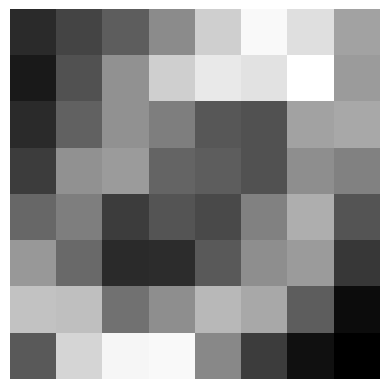

In [12]:
#We load the dataset
X = np.loadtxt('binarydigits.txt')

def MAP_parameters(input, alpha=3, beta=3):
    """
    Compute MAP estimates for Bernoulli parameters with a Beta(alpha, beta) prior.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Binary input data where X[n, d] ∈ {0, 1}.
    alpha : float, default=3
        Alpha hyperparameter of the Beta prior (pseudo-count of successes + 1).
    beta : float, default=3
        Beta hyperparameter of the Beta prior (pseudo-count of failures + 1).

    Returns
    -------
    P : numpy.ndarray of shape (n_features,)
        MAP estimates p̂[d] = (alpha - 1 + ∑ₙ X[n, d]) / (alpha + beta - 2 + N).
    """
    N, D = input.shape
    P=np.zeros(shape=D)
    for d in range (D):
        Pd=0
        for n in range (N):
            Pd+=input[n,d]
        P[d]=(-alpha+1-Pd)/(2-alpha-beta-N)
    return P

#We print the resulting image
plt.figure()
plt.imshow(np.reshape(MAP_parameters(X), (8,8)),interpolation="None",cmap='gray')
plt.axis('off')

print(MAP_parameters(X).reshape((8,8)))
print((100*(ML_parameters(X)-min(ML_parameters(X)))/(max(ML_parameters(X))-min(ML_parameters(X)))).reshape((8,8)))

print(100*(ML_parameters(X)-min(ML_parameters(X)))/(max(ML_parameters(X))-min(ML_parameters(X)))-100*(MAP_parameters(X)-min(MAP_parameters(X)))/(max(MAP_parameters(X))-min(MAP_parameters(X))))

### Exercice 2

In [ ]:
# We will use here the Decimal library to avoid overfloat/underfloat
getcontext().prec = 50

# We compute here the loglikelihood of the first model given our data
X = np.loadtxt('binarydigits.txt')
N,D=X.shape

#We work with log10 to avoir underfloat/overfloat
log_likelihood_1 = Decimal((N*D)*math.log10(1/2)) 


# We compute here the loglikelihood of the second model given our data
A = 0
for n in range (N):
    for d in range (D):
        A+=X[n][d]

log_likelihood_2 = Decimal(math.log10(math.factorial(int(A)))+
                         math.log10(math.factorial(D*N-int(A)))-
                         math.log10(math.factorial(D*N+1)))

# We compute here the loglikelihood of the third model given our data
log_likelihood_3 = Decimal(-D*math.log10(math.factorial(N-1)))
for d in range (D):
    alpha_d=0
    for n in range (N):
        alpha_d+=X[n][d]

    log_likelihood_3 += Decimal(math.log10(math.factorial(int(alpha_d))*
                                           math.factorial(N-int(alpha_d))))

#We compute here log(P(X))
log_P_X = np.log10(10**log_likelihood_1+10**log_likelihood_2+10**log_likelihood_3)

print("P(Mod1|X) = ", 10**(log_likelihood_1-log_P_X))
print("P(Mod2|X) = ", 10**(log_likelihood_2-log_P_X))
print("P(Mod3|X) = ", 10**(log_likelihood_3-log_P_X))

P(Mod1|X) =  4.8363769499747853665157291990610525393669292634886E-511
P(Mod2|X) =  7.5849251535414796062522576147162626414330066651175E-445
P(Mod3|X) =  1


### Exercice 3

##### Exercice 3 Question d

In [14]:
def E_step(P, pi, X):
    """
    Perform the expectation step of the EM algorithm.

    Parameters
    ----------
    P : array-like of shape (n_components, n_features)
        Current estimates of component-wise Bernoulli parameters.
    pi : array-like of shape (n_components,)
        Current estimates of mixture weights.
    X : array-like of shape (n_samples, n_features)
        Binary data matrix.

    Returns
    -------
    R : numpy.ndarray of shape (n_samples, n_components)
        Responsibility matrix where R[n, k] = P(z_n = k | x_n).
    """

    #We assign here a value to N, D and K, and we 
    # initialize our R matrix contaning all the r_{nk} 
    N,D=X.shape
    K=len(pi)
    R = np.zeros((N, K))

    #We compute here the formula found in 3.b
    for n in range(N):
        prod = []
        for k in range(K):
            prob_k = pi[k]
            for d in range(D):
                prob_k *= P[k][d]**X[n][d] * (1 - P[k][d])**(1 - X[n][d])
            prod.append(prob_k)
        total = sum(prod)
        
        # We Normalize R[n][k] by the sum to ensure it sums to one
        for k in range(K):
            R[n][k] = prod[k] / total if total != 0 else 1.0 / K
    return R

def M_step(X, R) :
    """
    Perform the maximization step of the EM algorithm.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Binary data matrix.
    R : array-like of shape (n_samples, n_components)
        Responsibility matrix from the E step.

    Returns
    -------
    P : numpy.ndarray of shape (n_components, n_features)
        Updated Bernoulli parameters for each component.
    pi : numpy.ndarray of shape (n_components,)
        Updated mixture weights.
    """

    #We assign here a value to N, D and K, and we 
    # initialize our pi matrix contaning all the pi_k, 
    # and our P matrix containing all the p_{kd}
    N,K = R.shape
    D=X.shape[1]
    pi = np.zeros(K)
    P = np.zeros((K, D))

    #We compute here the formula found in 3.c
    for k in range(K):
        N_k = np.sum(R[:, k])  # Total responsibility for cluster k
        pi[k] = N_k / N

        for d in range(D):
            # Weighted sum of X[n][d] for component k
            P[k][d] = np.sum(R[:, k] * X[:, d]) / N_k
    
    return P, pi

def log_likelihood(X, pi, P):
    """
    Compute the complete-data log-likelihood for a mixture of Bernoulli models.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Binary data matrix.
    pi : array-like of shape (n_components,)
        Mixture weights.
    P : array-like of shape (n_components, n_features)
        Bernoulli parameters for each component.

    Returns
    -------
    log_lik : float
        Sum of the log of the mixture probabilities over all samples.
    """

    log_lik = 0
    for n in range(X.shape[0]):
        temp_sum = 0

        for k in range(len(pi)):
            prob_k = pi[k]

            for d in range(P.shape[1]):
                prob_k *= P[k][d]**X[n][d] * (1 - P[k][d])**(1 - X[n][d])
            
            temp_sum += prob_k

        log_lik += np.log(temp_sum)

    return log_lik

def EM(K, X, max_iter, threshold):
    """
    Run the EM algorithm until convergence or max iterations.

    Parameters
    ----------
    K : int
        Number of mixture components.
    X : array-like of shape (n_samples, n_features)
        Binary data matrix.
    max_iter : int
        Maximum number of EM iterations.
    threshold : float
        Convergence threshold for change in log-likelihood.

    Returns
    -------
    R : numpy.ndarray of shape (n_samples, n_components)
        Final responsibility matrix.
    P : numpy.ndarray of shape (n_components, n_features)
        Final Bernoulli parameter estimates.
    pi : numpy.ndarray of shape (n_components,)
        Final mixture weight estimates.
    ll : list of float
        Log-likelihood values at each iteration.
    """
    #We assign a value to D
    D=X.shape[1]

    #We define randomly our initial Pi matrix
    pi_0 = np.random.rand(K)
    sum_pi=0
    for k in (pi_0):
        sum_pi+=k
    pi = pi_0/sum_pi

    #We define randomly our initial P matrix
    P = np.random.rand(K,D)

    #We compute the initial loglikelihood
    log_lik = log_likelihood(X, pi, P)
    ll=[log_lik]

    #We run the algorithm max_iter times
    for iteration in range(max_iter):
        #We update our R matrix during the E step
        R = E_step(P, pi, X)

        #We update our PI and P matrices during the M step
        P, pi = M_step(X, R)

        #We compute the new loglikelihood
        new_log_lik = log_likelihood(X, pi, P)
        
        # We check for convergence and stop the algorithm if it converges
        if abs(new_log_lik - log_lik) < threshold:
            #print(f"Converged at iteration {iteration}")
            break
        
        log_lik = new_log_lik
        ll.append(log_lik)
        #print(f"Iteration {iteration + 1}, Log-Likelihood: {log_lik}")

    return R, P, pi, ll

We print the log likelihood as a function of the number of iterations


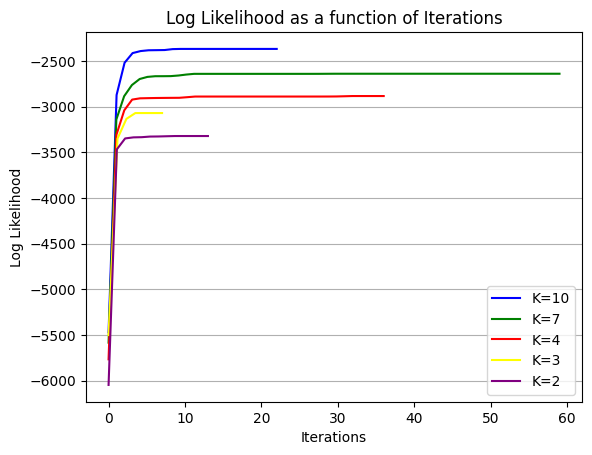

For K = 10, we have pi= [0.1500009  0.09000215 0.12000406 0.05998998 0.14       0.08000959
 0.04999695 0.04999627 0.16       0.10000009]
For K = 7, we have pi= [0.06       0.10000753 0.21923824 0.06999999 0.05999051 0.24077126
 0.24999246]
For K = 4, we have pi= [0.27001548 0.16998452 0.24990915 0.31009085]
For K = 3, we have pi= [0.70000001 0.17999999 0.12      ]
For K = 2, we have pi= [0.29998369 0.70001631]
For K = 10, we have P= [[1.33332532e-001 1.33332532e-001 1.99998798e-001 2.66671074e-001
  5.33336138e-001 8.00001202e-001 9.33333734e-001 9.33333734e-001
  0.00000000e+000 4.83486486e-132 1.33338541e-001 4.00003606e-001
  6.66668670e-001 5.33336138e-001 2.66671074e-001 1.99998798e-001
  0.00000000e+000 2.00004807e-001 4.66669872e-001 5.33330128e-001
  5.33330128e-001 1.33332532e-001 6.66662660e-002 1.33332532e-001
  1.33332532e-001 1.33338541e-001 6.66668670e-001 8.00001202e-001
  6.66662660e-001 5.99996394e-001 2.66665064e-001 1.33332532e-001
  1.54055609e-220 7.35481622e-121 1

In [15]:
print("We print the log likelihood as a function of the number of iterations")

#We define our y axis
R1, P1, pi1, y1=EM(10, X, 100, 1e-15)
R2, P2, pi2, y2=EM(7, X, 100, 1e-15)
R3, P3, pi3, y3=EM(4, X, 100, 1e-15)
R4, P4, pi4, y4=EM(3, X, 100, 1e-15)
R5, P5, pi5, y5=EM(2, X, 100, 1e-15)

#We define our x axis
x1 = np.linspace(0, len(y1), len(y1))
x2 = np.linspace(0, len(y2), len(y2))
x3 = np.linspace(0, len(y3), len(y3))
x4 = np.linspace(0, len(y4), len(y4))
x5 = np.linspace(0, len(y5), len(y5))

#We plot our axis
plt.plot(x1, y1, color='blue', label='K=10')
plt.plot(x2, y2, color='green', label='K=7')
plt.plot(x3, y3, color='red', label='K=4')
plt.plot(x4, y4, color='yellow', label='K=3')
plt.plot(x5, y5, color='purple', label='K=2')

#We define labels and titles for our graphs
plt.xlabel('Iterations')
plt.ylabel('Log Likelihood')
plt.grid(axis = "y")
plt.title('Log Likelihood as a function of Iterations')
plt.legend()  

#We show the result
plt.show()

#Print the parameters
print("For K = 10, we have pi=", pi1)
print("For K = 7, we have pi=", pi2)
print("For K = 4, we have pi=", pi3)
print("For K = 3, we have pi=", pi4)
print("For K = 2, we have pi=", pi5)

print("For K = 10, we have P=",P1)
print("For K = 7, we have P=", P2)
print("For K = 4, we have P=", P3)
print("For K = 3, we have P=", P4)
print("For K = 2, we have P=", P5)

print("For K = 10, we have R=",R1)
print("For K = 7, we have R=", R2)
print("For K = 4, we have R=", R3)
print("For K = 3, we have R=", R4)
print("For K = 2, we have R=", R5)

##### Exercice 3 Question e

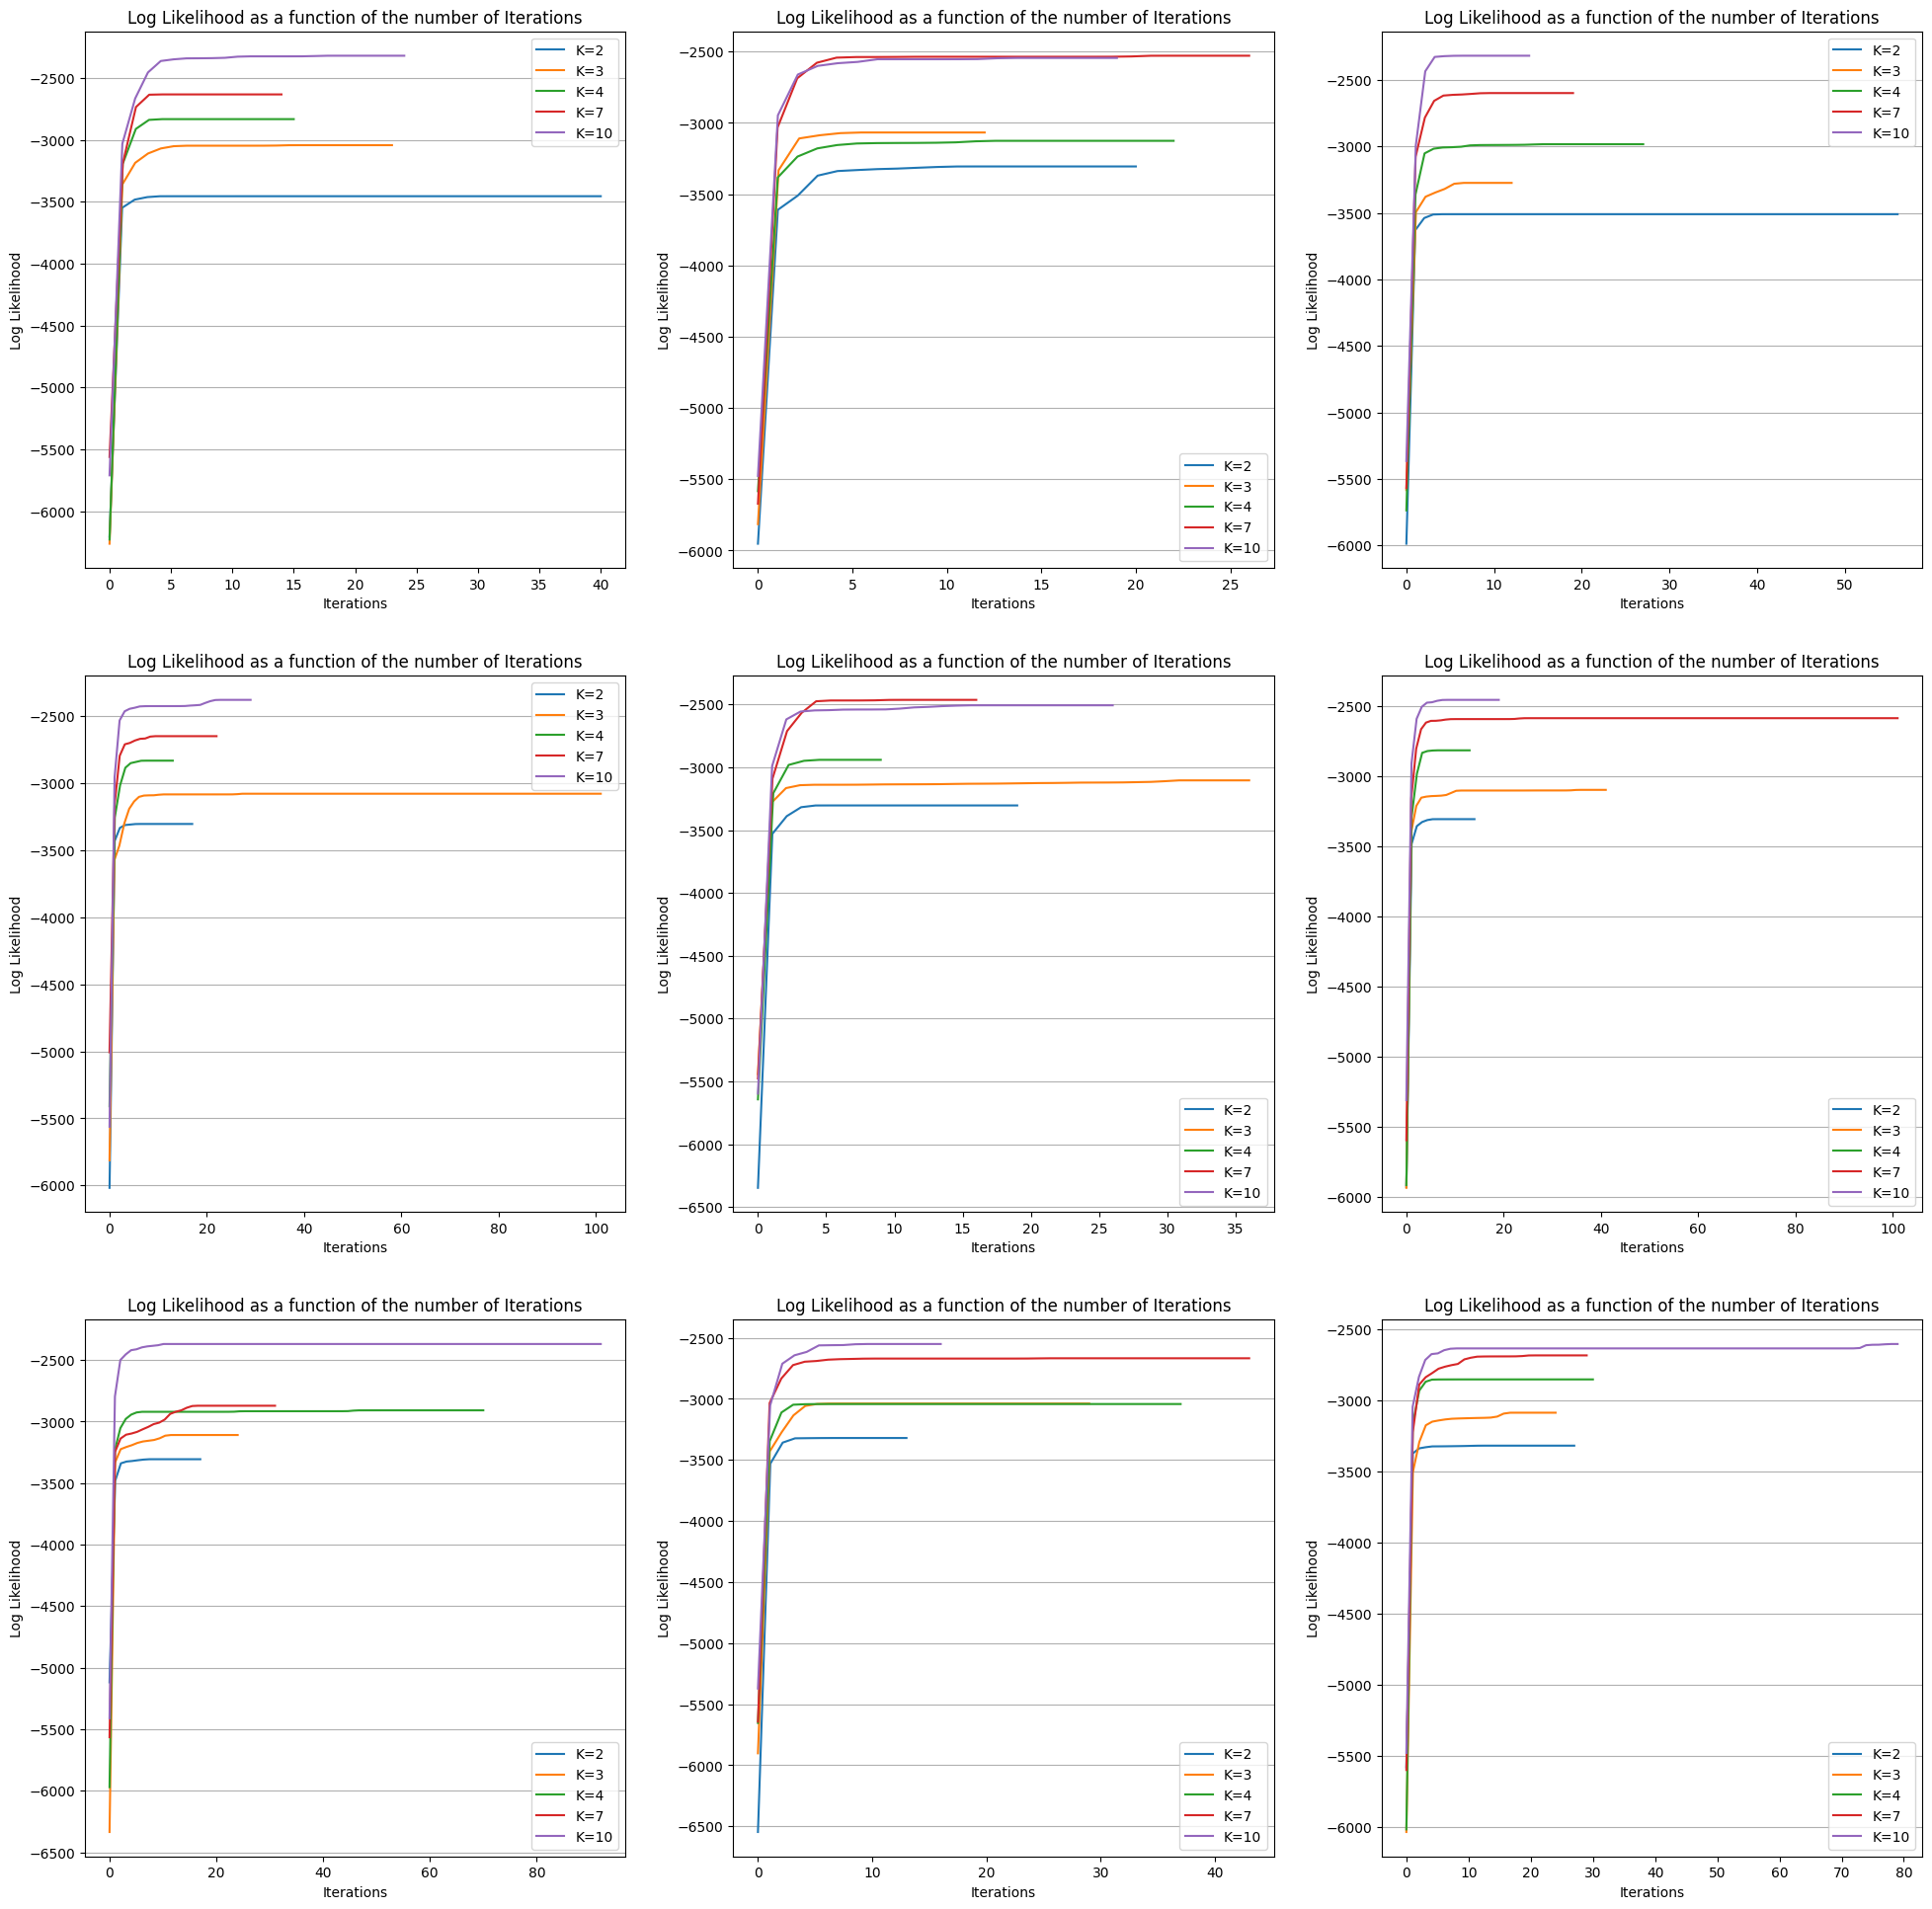

In [17]:
#We will there write commands to run the algorithm a 
# few times starting from randomly chosen initial conditions


def plot_various_K(obj,list=[2,3,4,7,10]):
    """
    Plot EM algorithm log-likelihood curves for multiple choices of K on a single Axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The Axes object on which to plot the log-likelihood curves.
    Ks : list of int, optional
        List of cluster counts K to evaluate with the EM algorithm (default is [2, 3, 4, 7, 10]).

    Returns
    -------
    R_list : list of numpy.ndarray
        List of responsibility matrices R from each EM run.
    P_list : list of numpy.ndarray
        List of parameter matrices P from each EM run.
    Pi_list : list of numpy.ndarray
        List of mixture-weight vectors pi from each EM run.
    """

    R_list, P_List, Pi_List=[], [], []
    for a in list : 
        #We use our EM function to generate 
        # the results of the EM algorithm
        R, P, pi, y1=EM(a, X, 100, 1e-15)
        R_list.append(R)
        P_List.append(P)
        Pi_List.append(pi)
        x1 = np.linspace(0, len(y1), len(y1))
        obj.plot(x1, y1, label='K='+str(a))
    
    #We define labels and titles for our graphs
    obj.set_xlabel('Iterations')
    obj.set_ylabel('Log Likelihood')
    obj.grid(axis = "y")
    obj.set_title('Log Likelihood as a function of the number of Iterations')
    obj.legend() 

    return R_list, P_List, Pi_List

# We instanciate our multiple graphs
fig, axs = plt.subplots(3, 3, figsize=(24, 24))

#We generate the graphs of the multiple simulations of our EM algorithm
for k in range(axs.shape[0]):
    for j in range(axs.shape[1]):
        R_list, P_List, Pi_List = plot_various_K(axs[k][j])
        #print("R_list for iteration", k+j+1," : ", R_list)
        #print("P_list for iteration", k+j+1," : ", P_List)
        #print("Pi_list for iteration", k+j+1," : ", Pi_List)

plt.show()

We plot our P matrices as images


<Figure size 640x480 with 0 Axes>

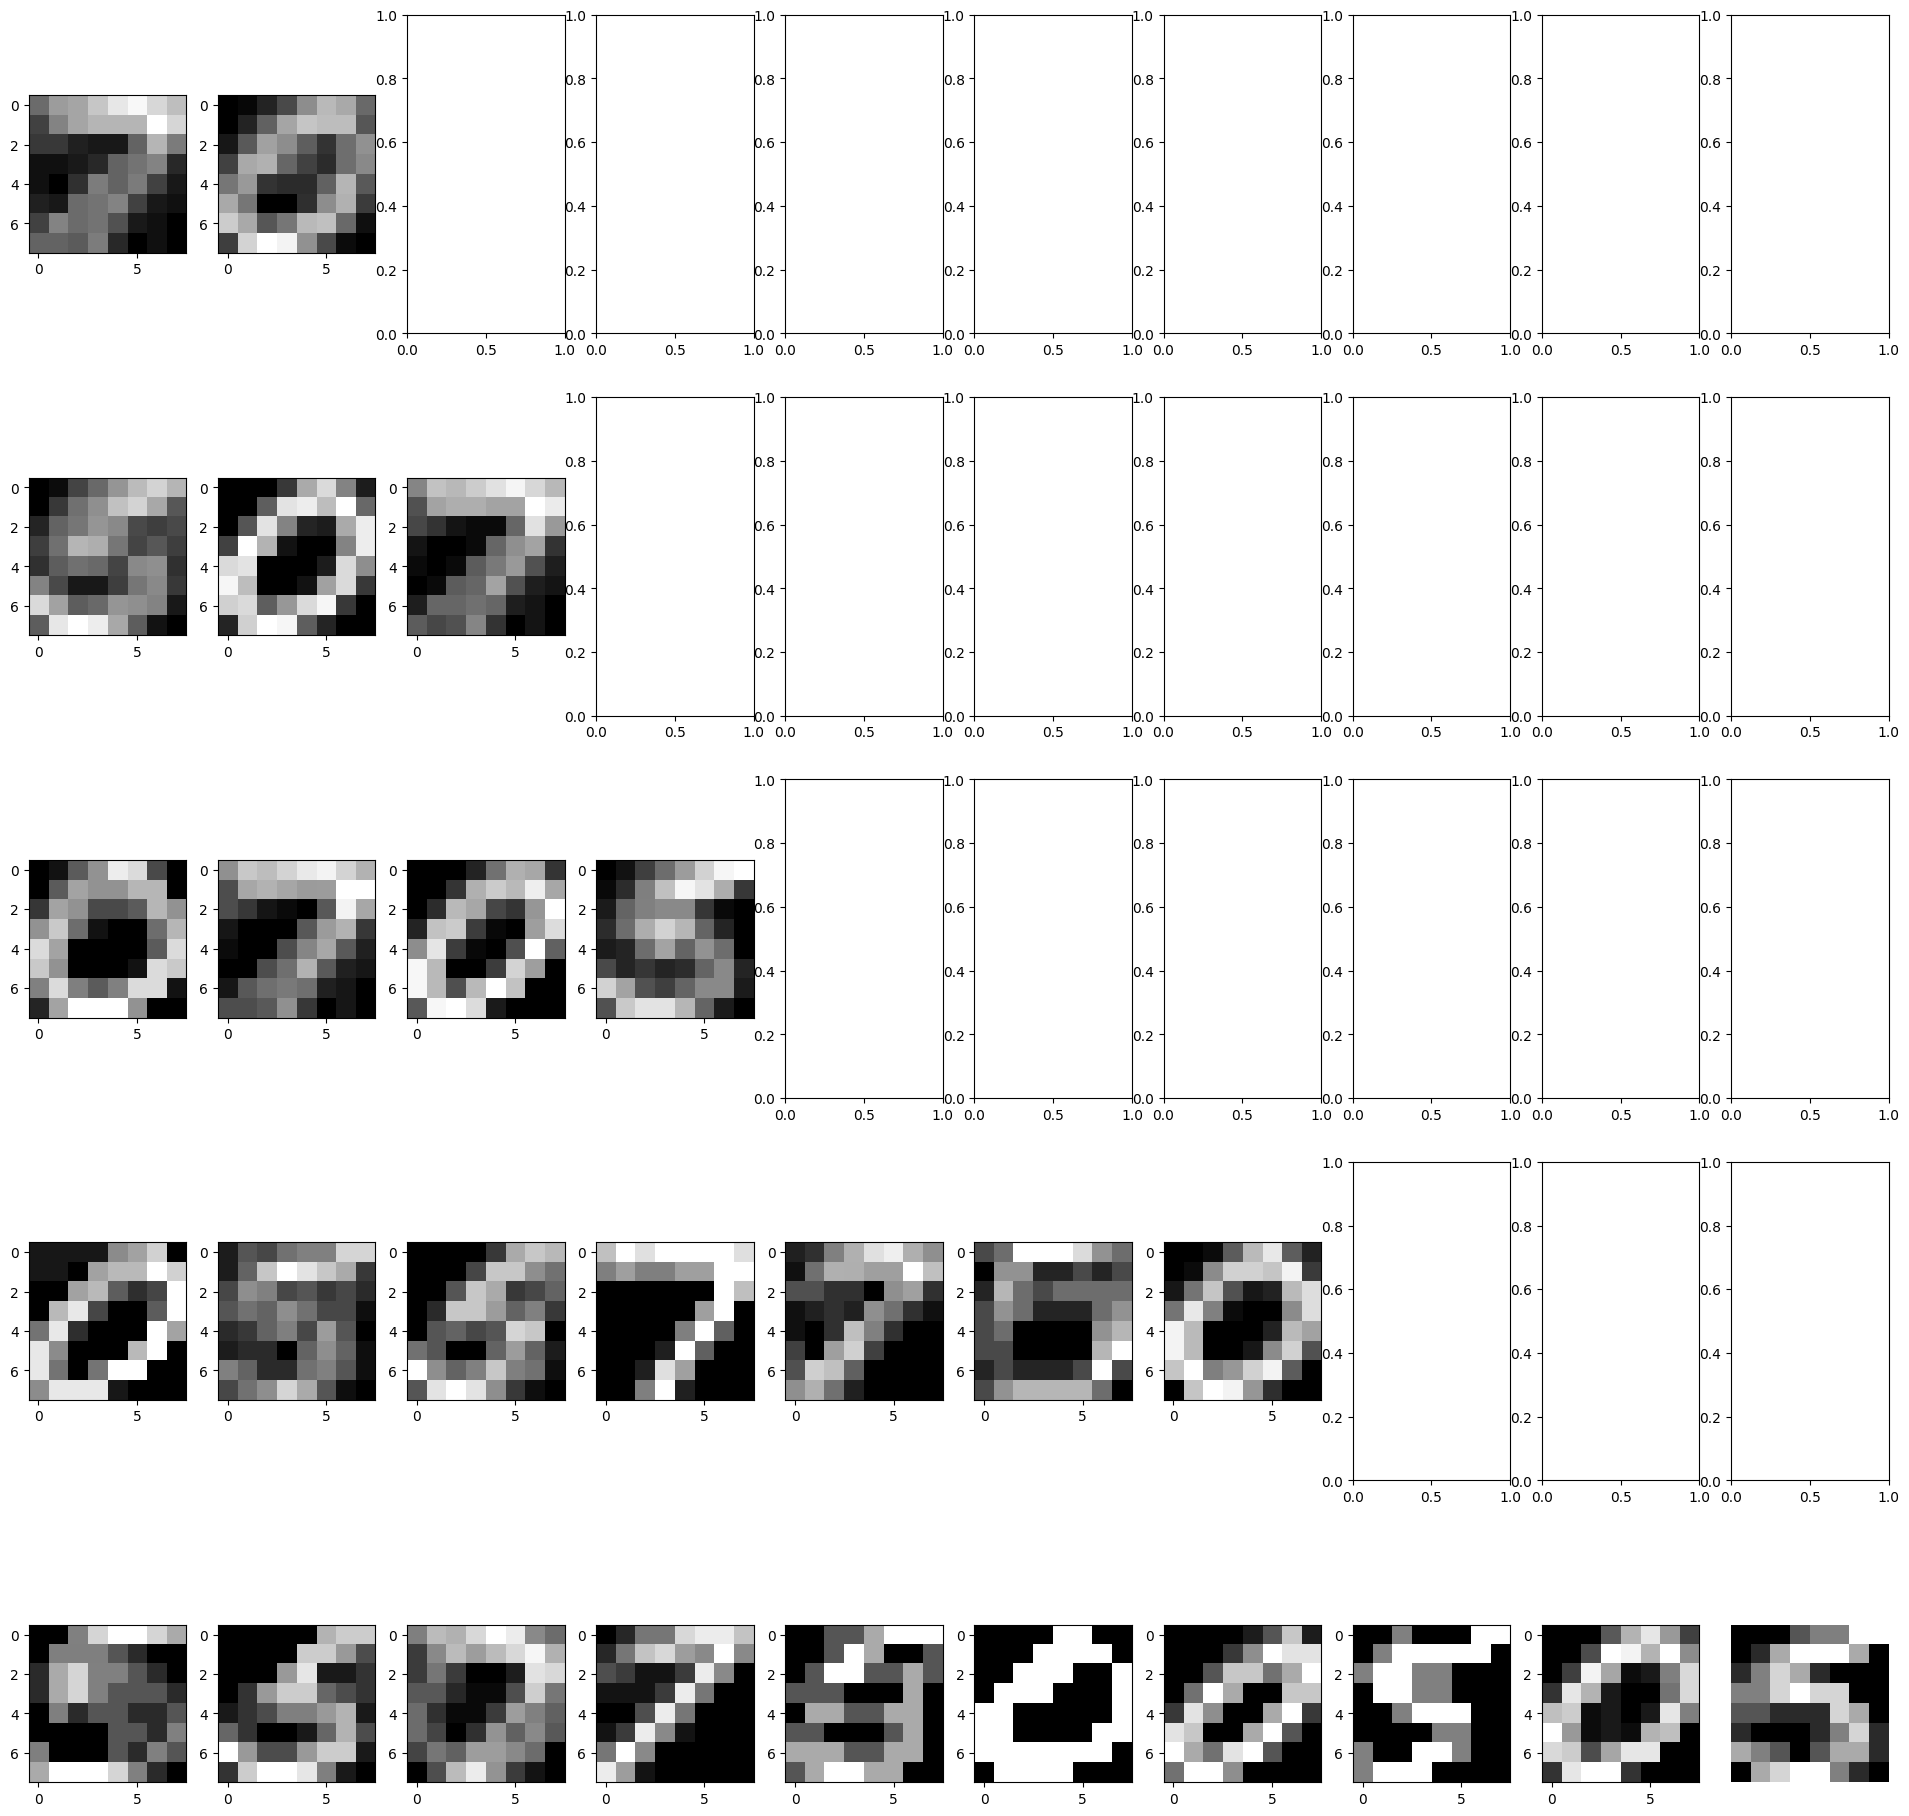

In [19]:
print("We plot our P matrices as images")

#We instanciate our graph
plt.figure()
fig, axs = plt.subplots(5, 10, figsize=(24, 24))

#We plot our P matrices as images in the instanciated graph
for k in range(len(P_List)):
    for l in range(len(P_List[k])):
        axs[k][l].imshow(np.reshape(P_List[k][l], (8, 8)), interpolation="None", cmap='gray')

plt.axis('off')
plt.show()

##### Exercice 3 Question g

In [20]:
def float_to_binary32(value):
    """
    Convert a Python float to its 32-bit IEEE 754 binary string representation.

    Parameters
    ----------
    value : float
        The floating-point number to encode.

    Returns
    -------
    binary_str : str
        A 32-character string of '0' and '1' bits corresponding to the IEEE 754 encoding.
    """
    
    packed_value = struct.pack('>f', value)
    # Unpack as an integer to get the binary representation
    bits = struct.unpack('>I', packed_value)[0]  
    return f'{bits:032b}'

ll=EM(10, X, 100, 1e-15)[3]
binary=[float_to_binary32(ll[k]) for k in range (len(ll))]
binary

['11000101101101101111101101111000',
 '11000101001110101101100111101100',
 '11000101001010101110100100111100',
 '11000101001001001110100110001111',
 '11000101001000011011011001001001',
 '11000101001000000010001101000101',
 '11000101000111100011111101111111',
 '11000101000111001010000100111110',
 '11000101000111001001010101011110',
 '11000101000111000111100010110001',
 '11000101000111000101001111100100',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101',
 '11000101000111000101001011011101']